In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.notebook import tqdm
import os

import dataset
import network
import nonlinearity
import train_network

plt.ioff()

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

Text(0.5, 1.0, 'Loss versus number of samples, log axes')

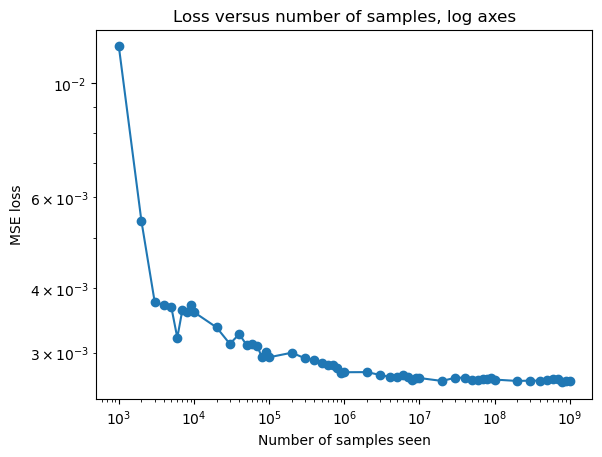

In [3]:
samples = np.load('net_checkpoints/samples.npy')
losses = np.load('net_checkpoints/losses.npy')
plt.loglog(samples, losses, marker='o')
plt.xlabel('Number of samples seen')
plt.ylabel('MSE loss')
plt.title('Loss versus number of samples, log axes')

In [4]:
scheduler = train_network.Scheduler()
network_shape = [3, 100, 100, 100, 2]

grid_points = 400
vec_grid_points = 20
hist_points = 100000
num_colors = max(network_shape)
colors = []
for i in range(num_colors):
    colors.append((np.random.uniform(0, 1), np.random.uniform(0, 1), np.random.uniform(0, 1)))
data_range = [-3, 3]

net = network.Network(network_shape, scheduler).to(device)
checkpoint = torch.load('network_final.pt', map_location=device)
net.load_state_dict(checkpoint['weights'])
net.eval();

(1, 5)


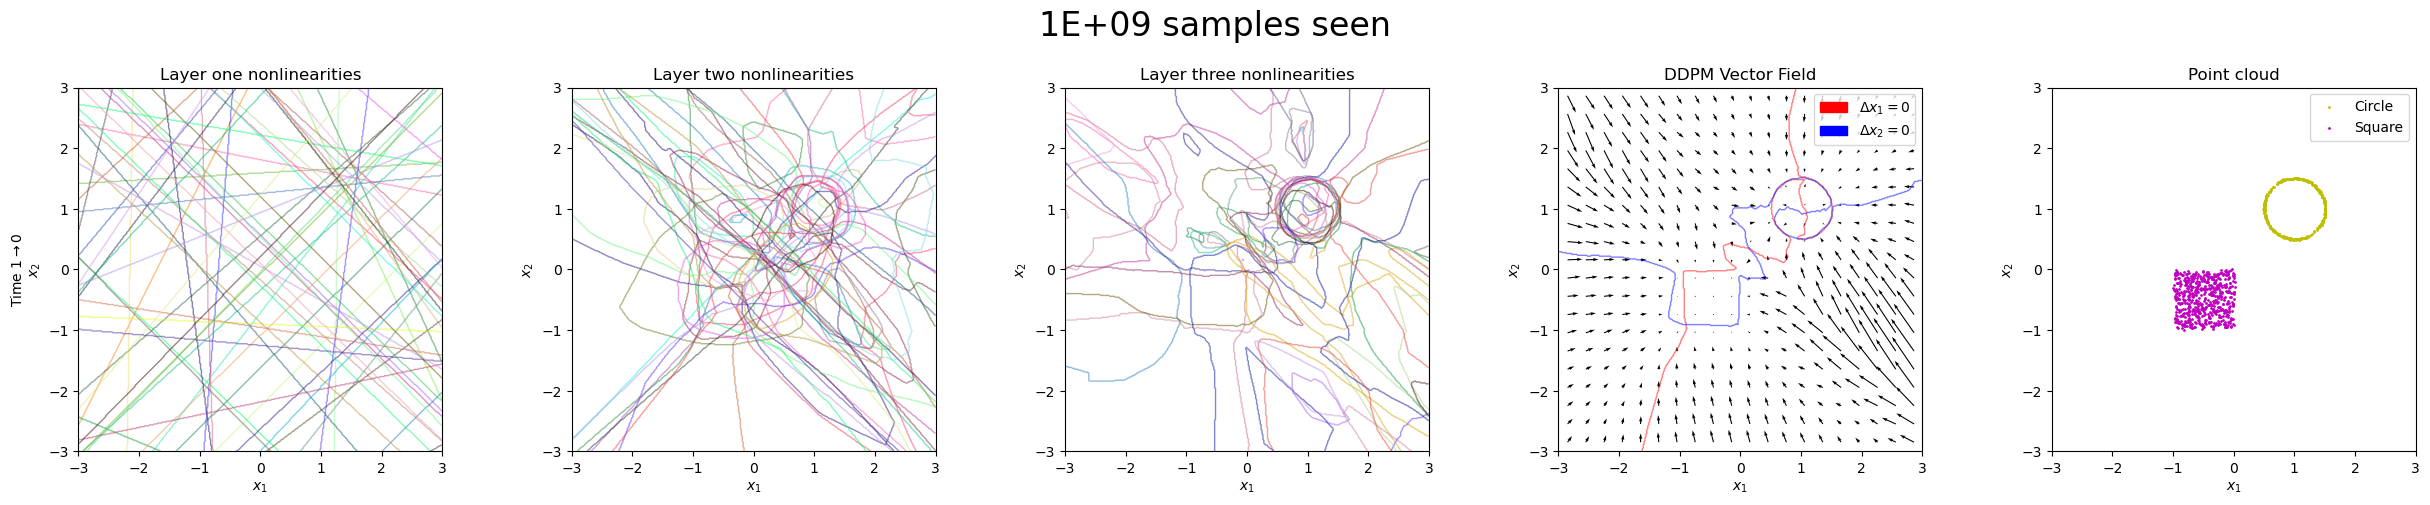

In [5]:
plotter = nonlinearity.Animator(net, colors, scheduler, data_range, 
                             grid_points, vec_grid_points, 
                             hist_points, device, is_DDPM=True)
plotter.draw_small(1e9, times=[0])
plt.show()

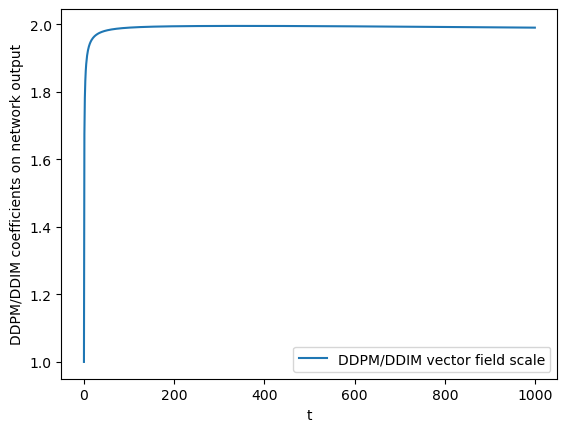

In [6]:
def vec_field_scale(sigma_scale):
    abar = np.insert(scheduler.alphabars, 0, 1)
    vec_field_scale = -np.sqrt(1 - abar[1:])
    vec_field_scale += np.sqrt(scheduler.alphas)*np.sqrt(1 - abar[:-1] - (sigma_scale*scheduler.sigmas)**2)
    return vec_field_scale

DDPM = vec_field_scale(1)
DDIM = vec_field_scale(0)
plt.plot(DDPM/DDIM, label='DDPM/DDIM vector field scale')
plt.legend()
plt.xlabel('t')
plt.ylabel('DDPM/DDIM coefficients on network output')
plt.show()

In [7]:
def pt_on_sphere():
    theta = np.random.uniform(0,2*np.pi)
    return [0.5*np.sin(theta)+1.0,0.5*np.cos(theta)+1.0]

def pt_in_square():
    x = np.random.uniform(0,1) - 1.0
    y = np.random.uniform(0,1) - 1.0
    return [x,y]

def generate_points(numpts):
    p = 0.2 #probability of point being on the circle (vs square)
    componenet = np.random.choice([0, 1], numpts, p=[1-p, p])
    pts = [pt_in_square() if comp == 0 else pt_on_sphere() for comp in componenet]
    return np.array(pts)

def forward_process_points(orig_points, gauss, scheduler, t):
    return np.sqrt(scheduler.alphabars[t])*orig_points + np.sqrt(1-scheduler.alphabars[t])*gauss

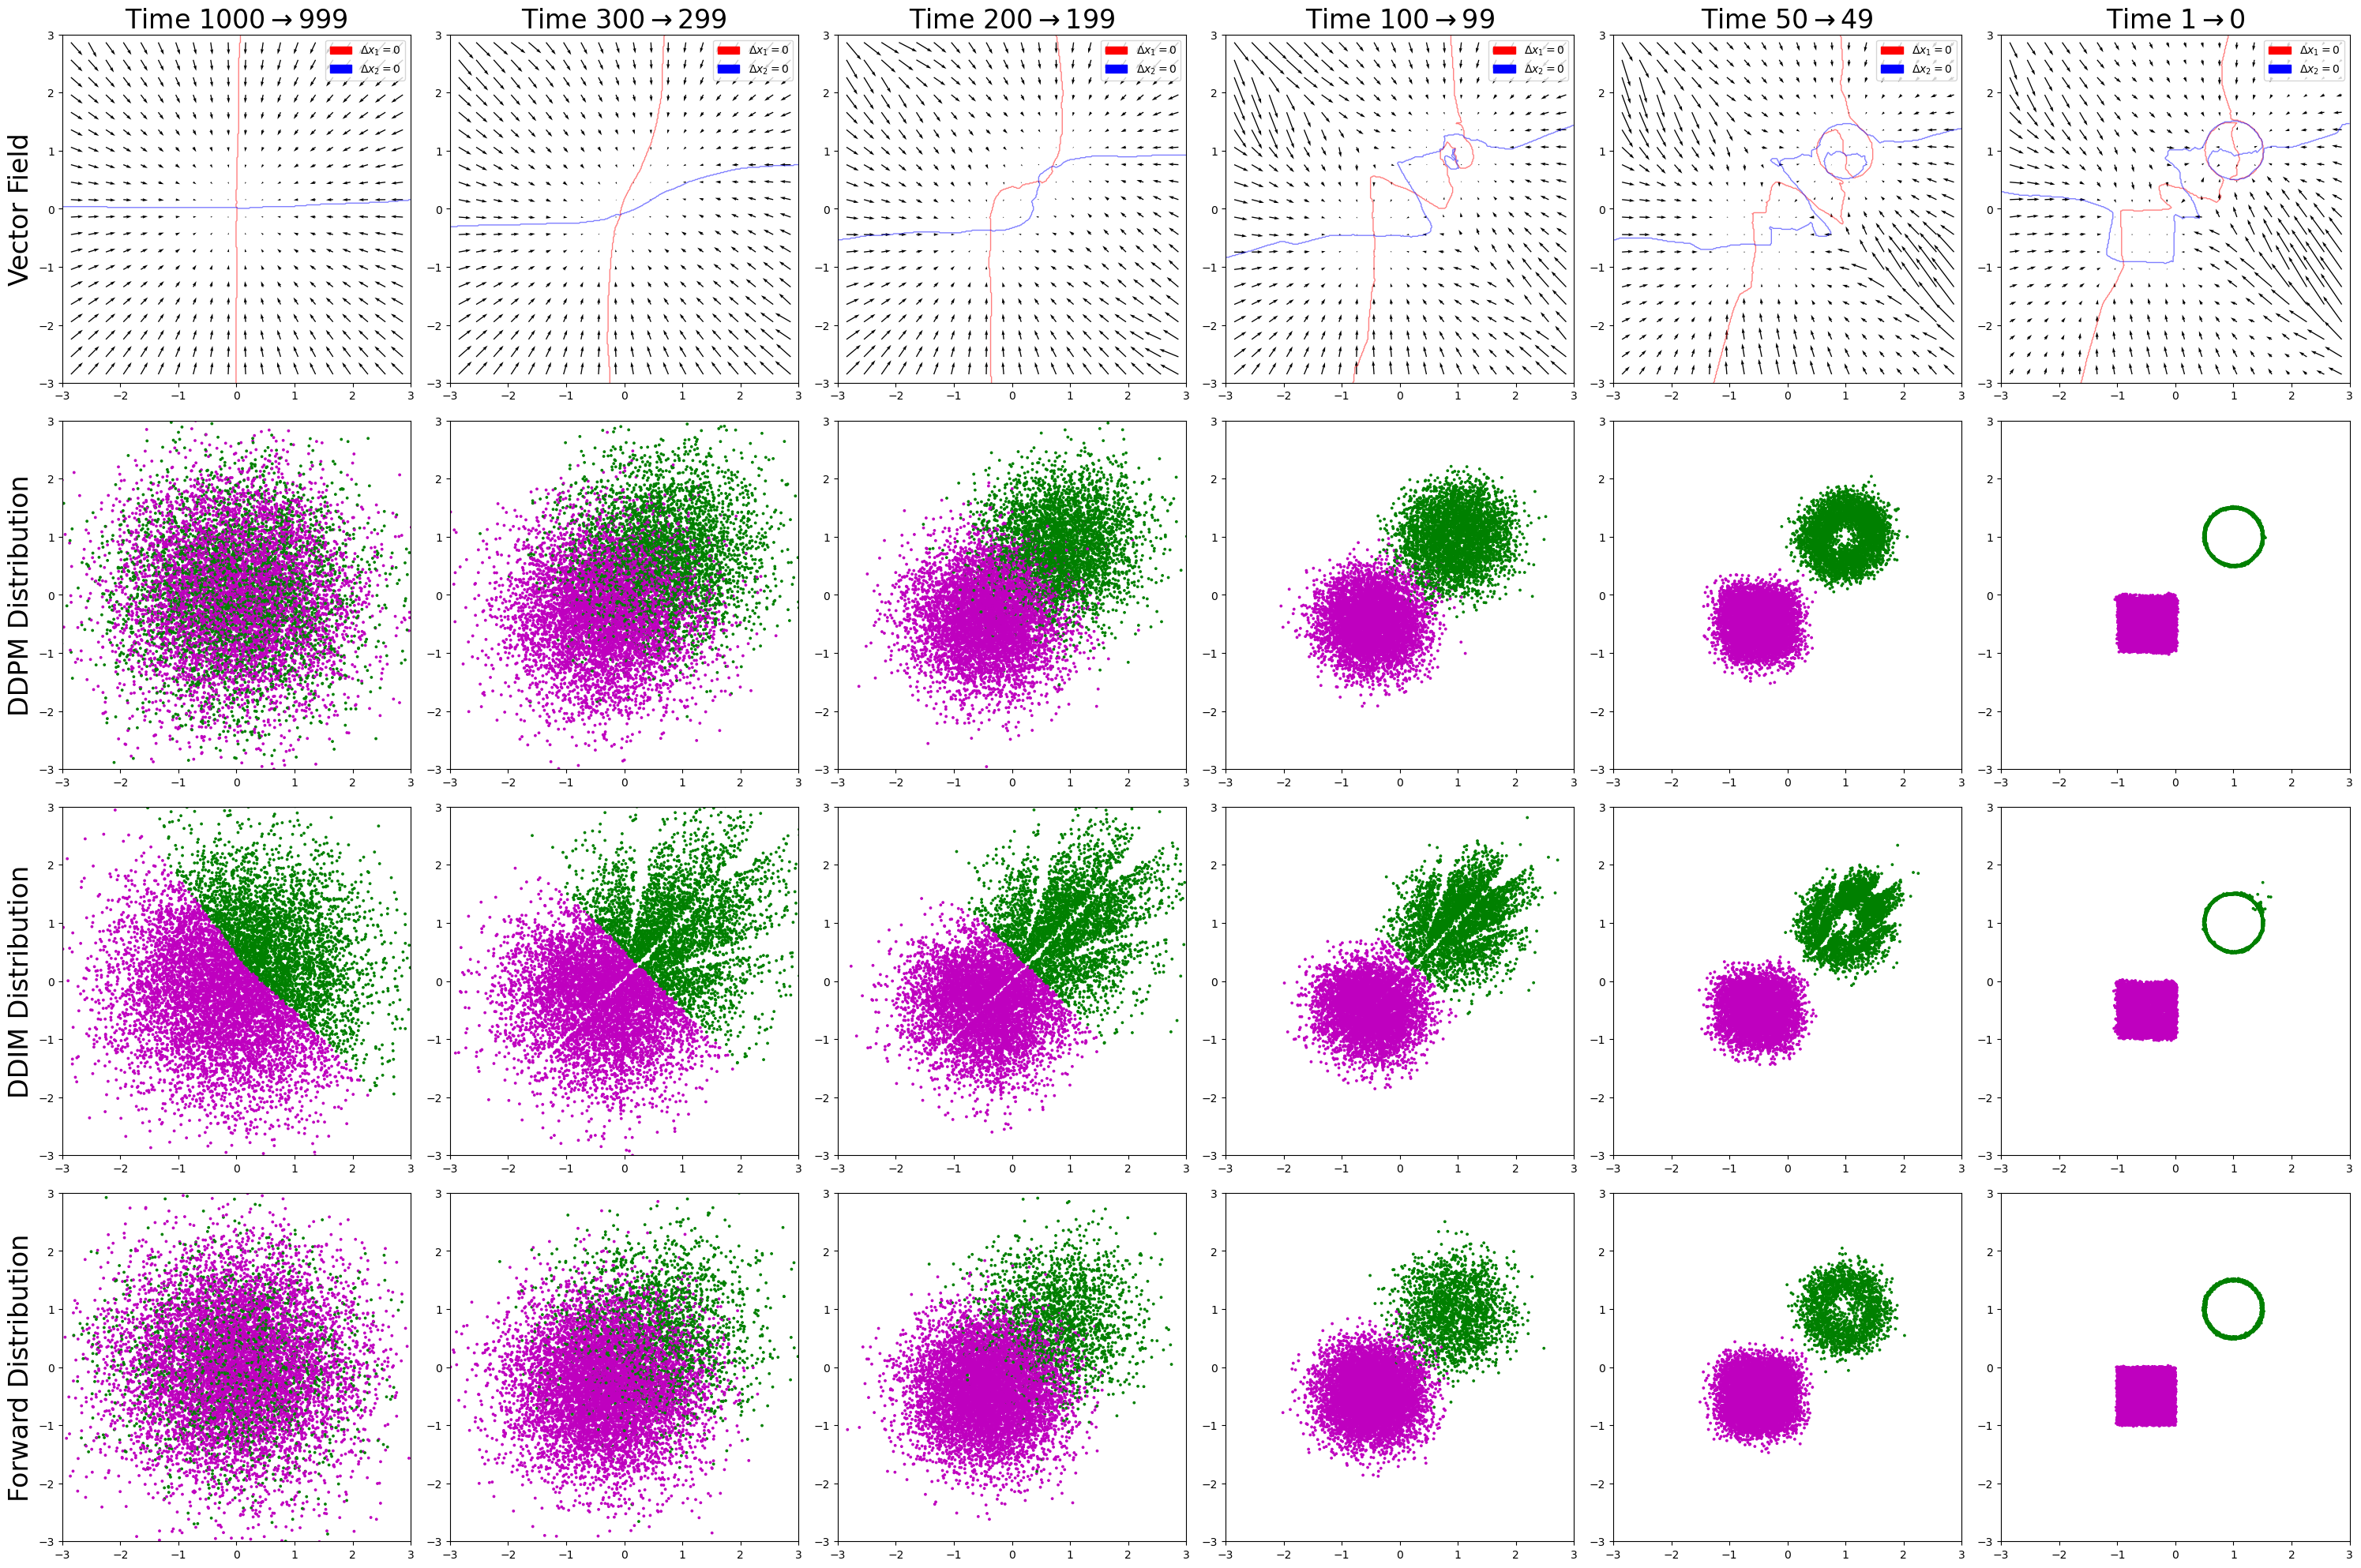

In [8]:
def plot_vec_field(axs, times, row, column, plotter):
    axs[row, column].quiver(plotter.X_vec, plotter.Y_vec, plotter.vec_field[:, :, 0], plotter.vec_field[:, :, 1])
    nonlinearity.plot_nullclines(plotter.X, plotter.Y, plotter.nullclines, axs[row, column])
    
def plot_scatter(axs, times, row, column, point_locs, up):
    npts = point_locs.shape[0]
    #axs[row,column].hist2d(point_locs[:, 0], point_locs[:, 1], density=True,
    #                       bins=100, cmap='inferno', range=[data_range, data_range])
    x = np.concatenate((point_locs[up, 0], point_locs[np.logical_not(up), 0]))
    y = np.concatenate((point_locs[up, 1], point_locs[np.logical_not(up), 1]))
    cols = np.concatenate((np.tile('g', sum(up)), np.tile('m', up.shape[0] - sum(up))))
    
    perm = np.random.permutation(range(up.shape[0]))
    
    axs[row, column].scatter(x[perm], y[perm], c=cols[perm], s=3)
    #axs[row, column].scatter(point_locs[up, 0], point_locs[up, 1], s=1, alpha=0.5, c='g')
    #axs[row, column].scatter(point_locs[np.logical_not(up), 0], point_locs[np.logical_not(up), 1], s=1, alpha=0.5, c='m')
    
times = [999, 299, 199, 99, 49, 0]

fig = plt.figure(figsize=(5*len(times), 5*4))
axs = fig.subplots(4, len(times))

for ax in fig.axes:
    ax.set_ylim([-3, 3])
    ax.set_xlim([-3, 3])
    ax.set_aspect('equal')
#     ax.set_xlabel('$x_1$')
#     ax.set_ylabel('$x_2$')

scatter_points = 10000

plotter_DDPM = nonlinearity.Animator(net, colors, scheduler, data_range, 
                                     grid_points, vec_grid_points, 
                                     scatter_points, device, is_DDPM=True)

plotter_DDIM = nonlinearity.Animator(net, colors, scheduler, data_range, 
                                     grid_points, vec_grid_points, 
                                     scatter_points, device, is_DDPM=False)

orig_points = generate_points(scatter_points)
gauss = np.random.normal(0, 1, (scatter_points, 2))

for i in range(len(times)):
    plotter_DDPM.calculate(times[i])
    plotter_DDIM.calculate(times[i])
    true_points = forward_process_points(orig_points, gauss, scheduler, times[i])
    
    axs[0, i].set_title(f'Time ${times[i]+1}\\to{times[i]}$', fontsize=24) 
    plot_vec_field(axs, times, 0, i, plotter_DDPM)
    axs[0, 0].set_ylabel('Vector Field', fontsize=24)
    
    plot_scatter(axs, times, 1, i, plotter_DDPM.point_locs, plotter_DDPM.up)
    axs[1, 0].set_ylabel('DDPM Distribution', fontsize=24)
    
    plot_scatter(axs, times, 2, i, plotter_DDIM.point_locs, plotter_DDIM.up)
    axs[2, 0].set_ylabel('DDIM Distribution', fontsize=24)
    
    plot_scatter(axs, times, 3, i, true_points, orig_points[:, 0] > 0)
    axs[3, 0].set_ylabel('Forward Distribution', fontsize=24)
    

fig.tight_layout()
plt.show()

In [9]:
animation_path = 'animation_e{}'
for degree in tqdm(range(3, 10)):
    net = network.Network(network_shape, scheduler).to(device)
    checkpoint = torch.load(f'net_checkpoints/network_e{degree}.pt', map_location=device)
    net.load_state_dict(checkpoint['weights'])
    net.eval();

    temp = nonlinearity.Animator(net, colors, scheduler, data_range, 
                                    grid_points, vec_grid_points, 
                                    hist_points, device, is_DDPM=True)
    
    formatted_path = animation_path.format(degree)
    temp.make_animation(formatted_path)
    os.system(f'ffmpeg -i {formatted_path}/%04d.png -r 12 nonlinear_animations/animation_trained_e{degree}.mp4')

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

ffmpeg version 4.2.2 Copyright (c) 2000-2019 the FFmpeg developers
  built with gcc 7.3.0 (crosstool-NG 1.23.0.449-a04d0)
  configuration: --prefix=/tmp/build/80754af9/ffmpeg_1587154242452/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placeho --cc=/tmp/build/80754af9/ffmpeg_1587154242452/_build_env/bin/x86_64-conda_cos6-linux-gnu-cc --disable-doc --enable-avresample --enable-gmp --enable-hardcoded-tables --enable-libfreetype --enable-libvpx --enable-pthreads --enable-libopus --enable-postproc --enable-pic --enable-pthreads --enable-shared --enable-static --enable-version3 --enable-zlib --enable-libmp3lame --disable-nonfree --enable-gpl --enable-gnutls --disable-openssl --enable-libopenh264 --enable-libx264
  libavutil      56. 31.100 / 56. 31.100
  libavcodec     58. 54.100 / 58. 54.100
  libavformat    58. 29.100 / 58. 29.100


  0%|          | 0/1000 [00:00<?, ?it/s]

ffmpeg version 4.2.2 Copyright (c) 2000-2019 the FFmpeg developers
  built with gcc 7.3.0 (crosstool-NG 1.23.0.449-a04d0)
  configuration: --prefix=/tmp/build/80754af9/ffmpeg_1587154242452/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placeho --cc=/tmp/build/80754af9/ffmpeg_1587154242452/_build_env/bin/x86_64-conda_cos6-linux-gnu-cc --disable-doc --enable-avresample --enable-gmp --enable-hardcoded-tables --enable-libfreetype --enable-libvpx --enable-pthreads --enable-libopus --enable-postproc --enable-pic --enable-pthreads --enable-shared --enable-static --enable-version3 --enable-zlib --enable-libmp3lame --disable-nonfree --enable-gpl --enable-gnutls --disable-openssl --enable-libopenh264 --enable-libx264
  libavutil      56. 31.100 / 56. 31.100
  libavcodec     58. 54.100 / 58. 54.100
  libavformat    58. 29.100 / 58. 29.100


...

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>